<a href="https://colab.research.google.com/github/Pam-Pam29/Summative-Assignment---Mission-Based-Reinforcement-Learning/blob/main/notebooks/fakunle_victoria_rl_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sista Health RL — Algorithm Comparison

This notebook loads the best trained models for DQN, PPO, and REINFORCE
and generates all comparison graphs required by the rubric:

- Cumulative reward curves (all methods in subplots)
- DQN objective curve
- PG entropy curves
- Convergence plot
- Generalization test
- Algorithm summary

## Step 1 — Install Libraries

In [1]:
!pip install gymnasium stable-baselines3 numpy pandas matplotlib seaborn -q
print('Libraries installed!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 11.9 MB/s eta 0:00:00
Libraries installed!


## Step 2 — Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os, shutil

# Copy models from Drive to local
os.makedirs('models/dqn', exist_ok=True)
os.makedirs('models/pg', exist_ok=True)
os.makedirs('results', exist_ok=True)

DRIVE = '/content/drive/MyDrive/sista_health_rl'

shutil.copy(f'{DRIVE}/models/dqn/best_dqn_model.zip',    'models/dqn/best_dqn_model.zip')
shutil.copy(f'{DRIVE}/models/pg/best_ppo_model.zip',     'models/pg/best_ppo_model.zip')
shutil.copy(f'{DRIVE}/models/pg/best_reinforce_model.zip','models/pg/best_reinforce_model.zip')

# Copy CSVs from Drive
shutil.copy(f'{DRIVE}/results/dqn_results.csv',       'results/dqn_results.csv')
shutil.copy(f'{DRIVE}/results/ppo_results.csv',       'results/ppo_results.csv')
shutil.copy(f'{DRIVE}/results/reinforce_results.csv', 'results/reinforce_results.csv')

print('All models and results loaded from Drive!')

Mounted at /content/drive
All models and results loaded from Drive!


## Step 3 — Define Sista Health Environment

In [3]:
import gymnasium as gym
import numpy as np
from gymnasium import spaces

class SistaHealthEnv(gym.Env):
    TOPICS    = ['FGM Complications','VVF Causes','Cultural Barriers',
                 'Early Marriage','TBA Dangers','Contraception',
                 'STIs & HIV','Antenatal Care','Postpartum Care']
    LANGUAGES = ['English','Yoruba','Pidgin']
    DOMAINS   = ['Sexual Health','Maternal Health']
    ACTIONS   = ['Text Response','Voice Note','Emergency Referral','Clarify']

    def __init__(self):
        super().__init__()
        self.observation_space = spaces.Box(
            low=np.array([0,0,0,0,0,0], dtype=np.float32),
            high=np.array([2,1,8,1,2,9], dtype=np.float32),
            dtype=np.float32
        )
        self.action_space   = spaces.Discrete(4)
        self.state          = None
        self.step_count     = 0
        self.episode_reward = 0

    def _get_obs(self): return self.state.astype(np.float32)
    def _get_info(self):
        return {
            'language': self.LANGUAGES[int(self.state[0])],
            'domain':   self.DOMAINS[int(self.state[1])],
            'topic':    self.TOPICS[int(self.state[2])],
            'urgency':  'Emergency' if self.state[3]==1 else 'Normal',
            'literacy': ['Low','Medium','High'][int(self.state[4])],
        }

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.state = np.array([
            self.np_random.integers(0,3), self.np_random.integers(0,2),
            self.np_random.integers(0,9), 1 if self.np_random.random()<0.2 else 0,
            self.np_random.integers(0,3), 0
        ], dtype=np.float32)
        self.step_count=0; self.episode_reward=0
        return self._get_obs(), self._get_info()

    def step(self, action):
        urgency=int(self.state[3]); literacy=int(self.state[4]); language=int(self.state[0])
        reward=0; terminated=False
        if action==2:
            if urgency==1: reward+=10; terminated=True
            else: reward-=3
        elif action==0:
            if urgency==1: reward-=10
            elif literacy==2: reward+=5
            elif literacy==1: reward+=2
            else: reward-=2
        elif action==1:
            if urgency==1: reward-=10
            elif literacy==0: reward+=10
            elif literacy==1: reward+=5
            else: reward+=1
            if language==2: reward+=1
        elif action==3:
            if urgency==1: reward-=2
            else: reward+=1
        self.state[5]=min(self.state[5]+1,9); self.step_count+=1
        self.episode_reward+=reward
        if self.step_count>=10: terminated=True
        return self._get_obs(), reward, terminated, False, self._get_info()

    def render(self): pass
    def close(self): pass

print('Environment defined!')

Environment defined!


## Step 4 — Load All 3 Models

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
matplotlib.rcParams['figure.dpi'] = 120
sns.set(style='darkgrid')
from stable_baselines3 import DQN, PPO, A2C

dqn_model = DQN.load('models/dqn/best_dqn_model')
ppo_model = PPO.load('models/pg/best_ppo_model')
rf_model  = A2C.load('models/pg/best_reinforce_model')

print('All 3 models loaded!')
print('  DQN       - best_dqn_model')
print('  PPO       - best_ppo_model')
print('  REINFORCE - best_reinforce_model')

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


All 3 models loaded!
  DQN       - best_dqn_model
  PPO       - best_ppo_model
  REINFORCE - best_reinforce_model


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run A2C on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force 

## Step 5 — Collect Episode Data (100 episodes each)

In [5]:
def collect_rewards(model, n_episodes=100, seed=42):
    env = SistaHealthEnv()
    rewards = []
    for i in range(n_episodes):
        obs, _ = env.reset(seed=seed+i)
        ep_r, done = 0, False
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, r, term, trunc, _ = env.step(int(action))
            ep_r += r
            done = term or trunc
        rewards.append(ep_r)
    env.close()
    return rewards

def smooth(data, window=10):
    if len(data) < window:
        return np.array(data)
    return np.convolve(data, np.ones(window)/window, mode='valid')

print('Collecting 100 episodes per algorithm...')
dqn_rewards = collect_rewards(dqn_model)
ppo_rewards = collect_rewards(ppo_model)
rf_rewards  = collect_rewards(rf_model)

print(f'DQN       mean: {np.mean(dqn_rewards):.2f} std: {np.std(dqn_rewards):.2f}')
print(f'PPO       mean: {np.mean(ppo_rewards):.2f} std: {np.std(ppo_rewards):.2f}')
print(f'REINFORCE mean: {np.mean(rf_rewards):.2f} std: {np.std(rf_rewards):.2f}')
print('Done!')

DQN       mean: 55.92 std: 32.51
PPO       mean: 56.40 std: 31.35
REINFORCE mean: 46.10 std: 37.39
Done!


## Step 6 — Graph 1: Cumulative Reward Curves (All Methods)

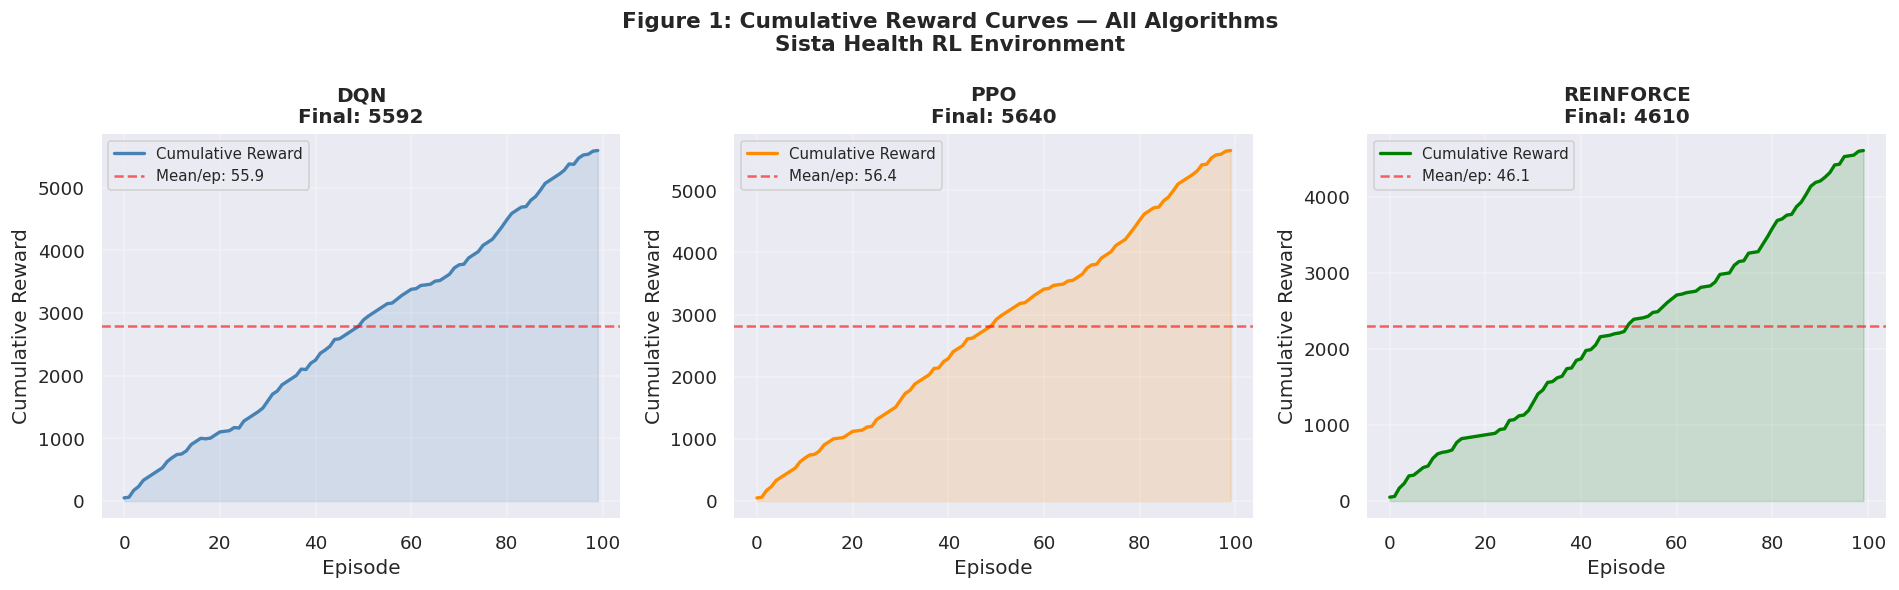

Saved: graph1_cumulative_rewards.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Figure 1: Cumulative Reward Curves — All Algorithms\nSista Health RL Environment',
             fontsize=13, fontweight='bold')

algo_data = [
    ('DQN',       dqn_rewards, 'steelblue'),
    ('PPO',       ppo_rewards, 'darkorange'),
    ('REINFORCE', rf_rewards,  'green'),
]

for ax, (name, rewards, color) in zip(axes, algo_data):
    cumulative = np.cumsum(rewards)
    ax.plot(cumulative, color=color, linewidth=2, label='Cumulative Reward')
    ax.fill_between(range(len(cumulative)), cumulative, alpha=0.15, color=color)
    ax.axhline(np.mean(rewards)*50, color='red', linestyle='--',
               alpha=0.6, label=f'Mean/ep: {np.mean(rewards):.1f}')
    ax.set_title(f'{name}\nFinal: {cumulative[-1]:.0f}', fontweight='bold')
    ax.set_xlabel('Episode')
    ax.set_ylabel('Cumulative Reward')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('results/graph1_cumulative_rewards.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: graph1_cumulative_rewards.png')

## Step 7 — Graph 2: DQN Objective Curve

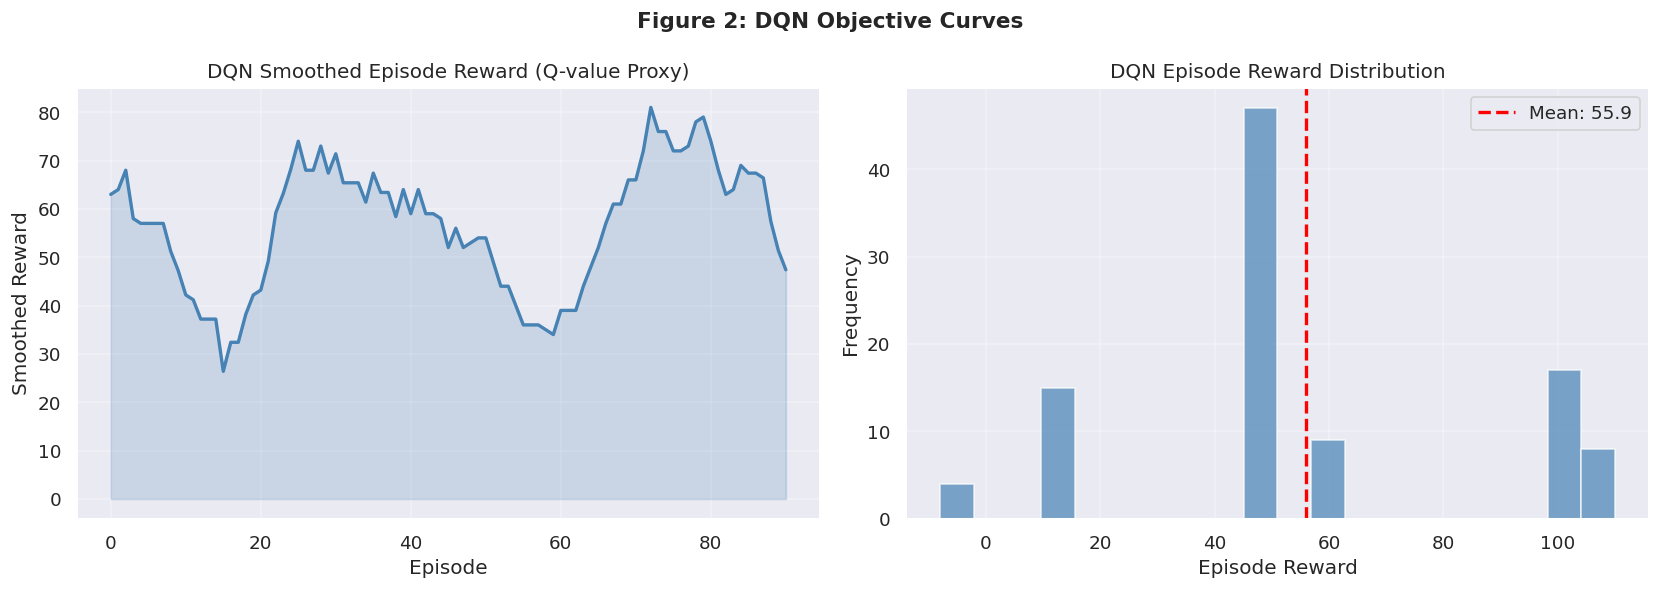

Saved: graph2_dqn_objective.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figure 2: DQN Objective Curves', fontsize=13, fontweight='bold')

dqn_smooth = smooth(dqn_rewards, window=10)
axes[0].plot(dqn_smooth, color='steelblue', linewidth=2)
axes[0].fill_between(range(len(dqn_smooth)), dqn_smooth, alpha=0.2, color='steelblue')
axes[0].set_title('DQN Smoothed Episode Reward (Q-value Proxy)')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Smoothed Reward')
axes[0].grid(alpha=0.3)

axes[1].hist(dqn_rewards, bins=20, color='steelblue', alpha=0.7, edgecolor='white')
axes[1].axvline(np.mean(dqn_rewards), color='red', linestyle='--',
                linewidth=2, label=f'Mean: {np.mean(dqn_rewards):.1f}')
axes[1].set_title('DQN Episode Reward Distribution')
axes[1].set_xlabel('Episode Reward')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('results/graph2_dqn_objective.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: graph2_dqn_objective.png')

## Step 8 — Graph 3: Policy Gradient Entropy Curves

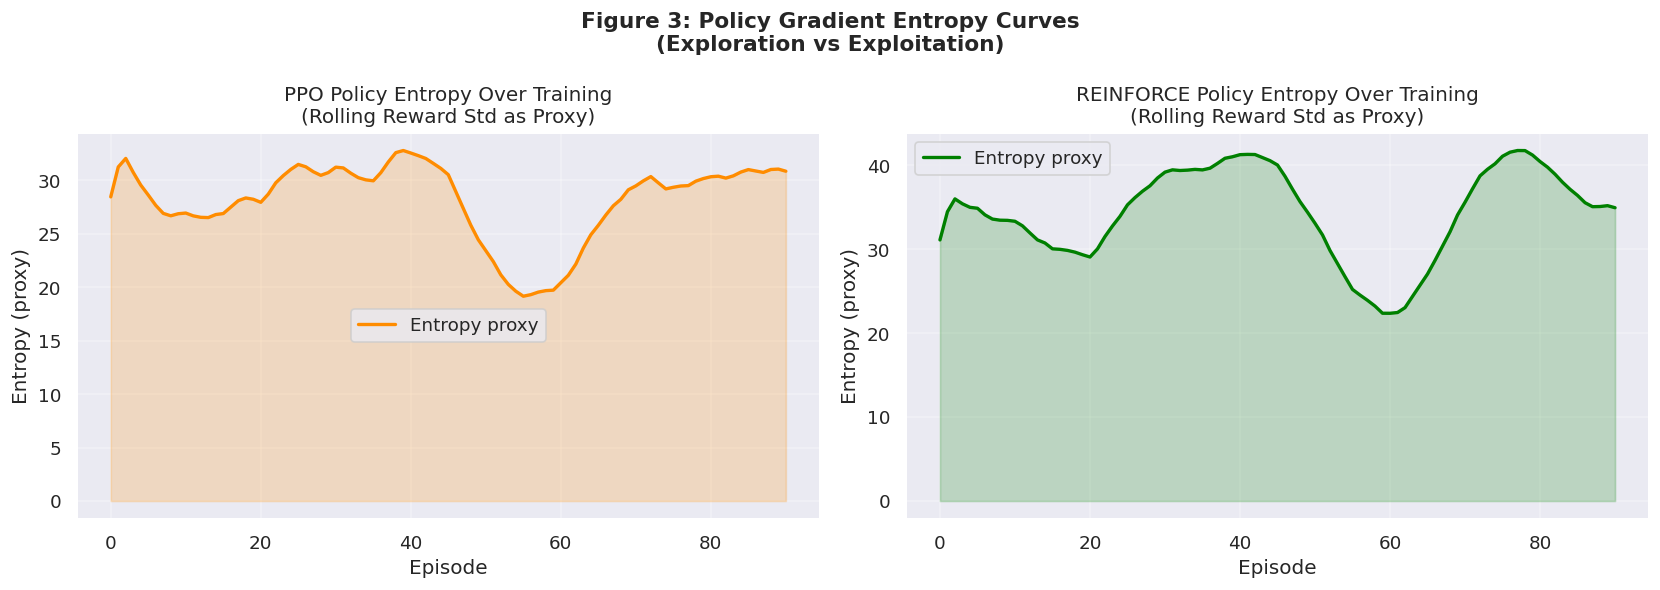

Saved: graph3_entropy_curves.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figure 3: Policy Gradient Entropy Curves\n(Exploration vs Exploitation)',
             fontsize=13, fontweight='bold')

for ax, (rewards, name, color) in zip(axes,
    [(ppo_rewards,'PPO','darkorange'), (rf_rewards,'REINFORCE','green')]):
    entropy_proxy = [np.std(rewards[max(0,i-10):i+1]) for i in range(len(rewards))]
    smoothed_ent  = smooth(entropy_proxy, 10)
    ax.plot(smoothed_ent, color=color, linewidth=2, label='Entropy proxy')
    ax.fill_between(range(len(smoothed_ent)), smoothed_ent, alpha=0.2, color=color)
    ax.set_title(f'{name} Policy Entropy Over Training\n(Rolling Reward Std as Proxy)')
    ax.set_xlabel('Episode')
    ax.set_ylabel('Entropy (proxy)')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('results/graph3_entropy_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: graph3_entropy_curves.png')

## Step 9 — Graph 4: Convergence Plot (All Algorithms)

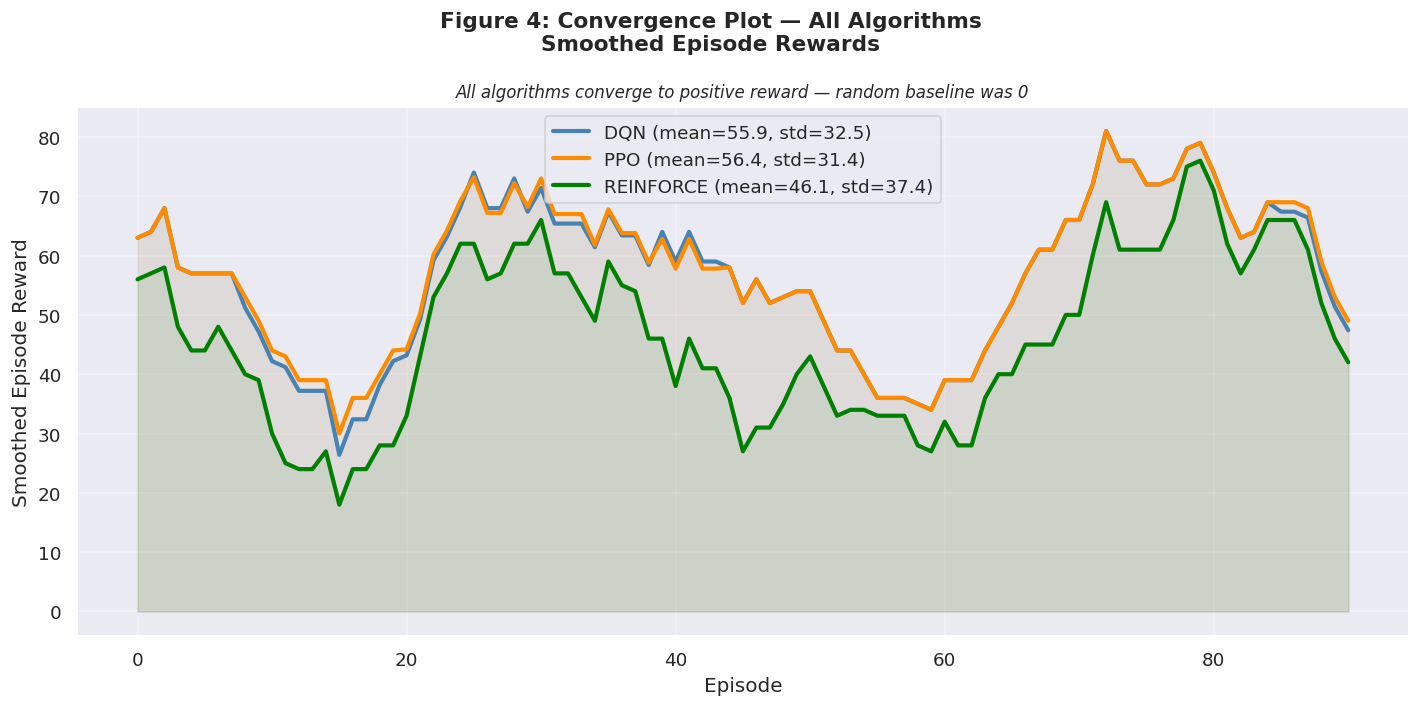

Saved: graph4_convergence.png


In [9]:
fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle('Figure 4: Convergence Plot — All Algorithms\nSmoothed Episode Rewards',
             fontsize=13, fontweight='bold')

for rewards, name, color in [
    (dqn_rewards, 'DQN',       'steelblue'),
    (ppo_rewards, 'PPO',       'darkorange'),
    (rf_rewards,  'REINFORCE', 'green'),
]:
    s = smooth(rewards, 10)
    ax.plot(s, color=color, linewidth=2.5,
            label=f'{name} (mean={np.mean(rewards):.1f}, std={np.std(rewards):.1f})')
    ax.fill_between(range(len(s)), s, alpha=0.08, color=color)

ax.set_xlabel('Episode', fontsize=12)
ax.set_ylabel('Smoothed Episode Reward', fontsize=12)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
ax.set_title('All algorithms converge to positive reward — random baseline was 0',
             fontsize=10, style='italic')

plt.tight_layout()
plt.savefig('results/graph4_convergence.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: graph4_convergence.png')

## Step 10 — Graph 5: Generalization Test

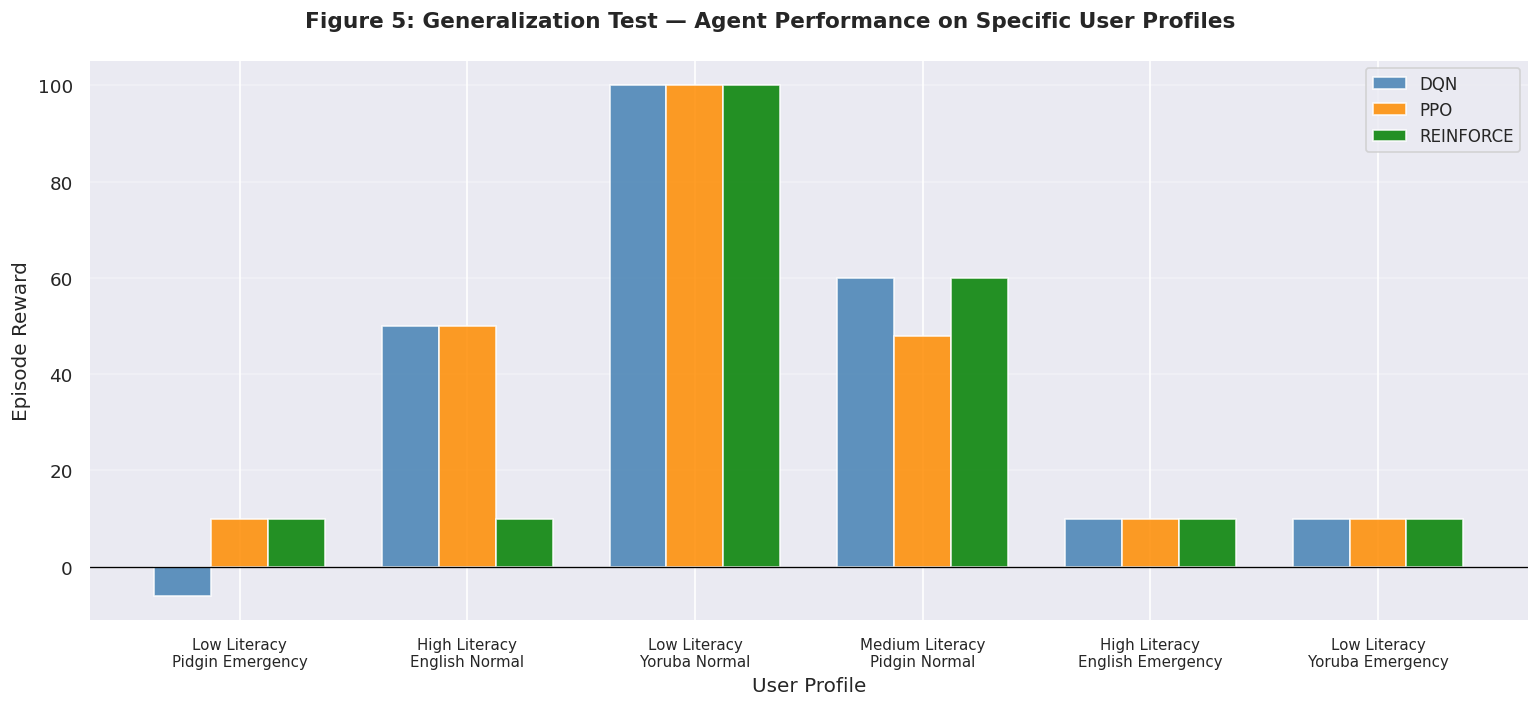

Saved: graph5_generalization.png


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [10]:
test_profiles = [
    {'name': 'Low Literacy\nPidgin Emergency',  'obs': [2,1,0,1,0,0]},
    {'name': 'High Literacy\nEnglish Normal',   'obs': [0,0,5,0,2,0]},
    {'name': 'Low Literacy\nYoruba Normal',      'obs': [1,1,3,0,0,0]},
    {'name': 'Medium Literacy\nPidgin Normal',   'obs': [2,0,6,0,1,0]},
    {'name': 'High Literacy\nEnglish Emergency', 'obs': [0,1,8,1,2,0]},
    {'name': 'Low Literacy\nYoruba Emergency',   'obs': [1,0,2,1,0,0]},
]

gen_results = {'DQN':[], 'PPO':[], 'REINFORCE':[]}

for profile in test_profiles:
    obs_arr = np.array(profile['obs'], dtype=np.float32)
    for model, name in [(dqn_model,'DQN'),(ppo_model,'PPO'),(rf_model,'REINFORCE')]:
        env = SistaHealthEnv()
        env.reset()
        env.state = obs_arr.copy()
        total_r, done = 0, False
        while not done:
            action, _ = model.predict(env.state, deterministic=True)
            _, r, term, trunc, _ = env.step(int(action))
            total_r += r
            done = term or trunc
        gen_results[name].append(total_r)
        env.close()

fig, ax = plt.subplots(figsize=(13, 6))
fig.suptitle('Figure 5: Generalization Test — Agent Performance on Specific User Profiles',
             fontsize=13, fontweight='bold')

x     = np.arange(len(test_profiles))
width = 0.25
labels = [p['name'] for p in test_profiles]

ax.bar(x - width, gen_results['DQN'],       width, label='DQN',       color='steelblue',  alpha=0.85)
ax.bar(x,         gen_results['PPO'],       width, label='PPO',       color='darkorange', alpha=0.85)
ax.bar(x + width, gen_results['REINFORCE'], width, label='REINFORCE', color='green',      alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('Episode Reward')
ax.set_xlabel('User Profile')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.axhline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig('results/graph5_generalization.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: graph5_generalization.png')

## Step 11 — Graph 6: Algorithm Summary

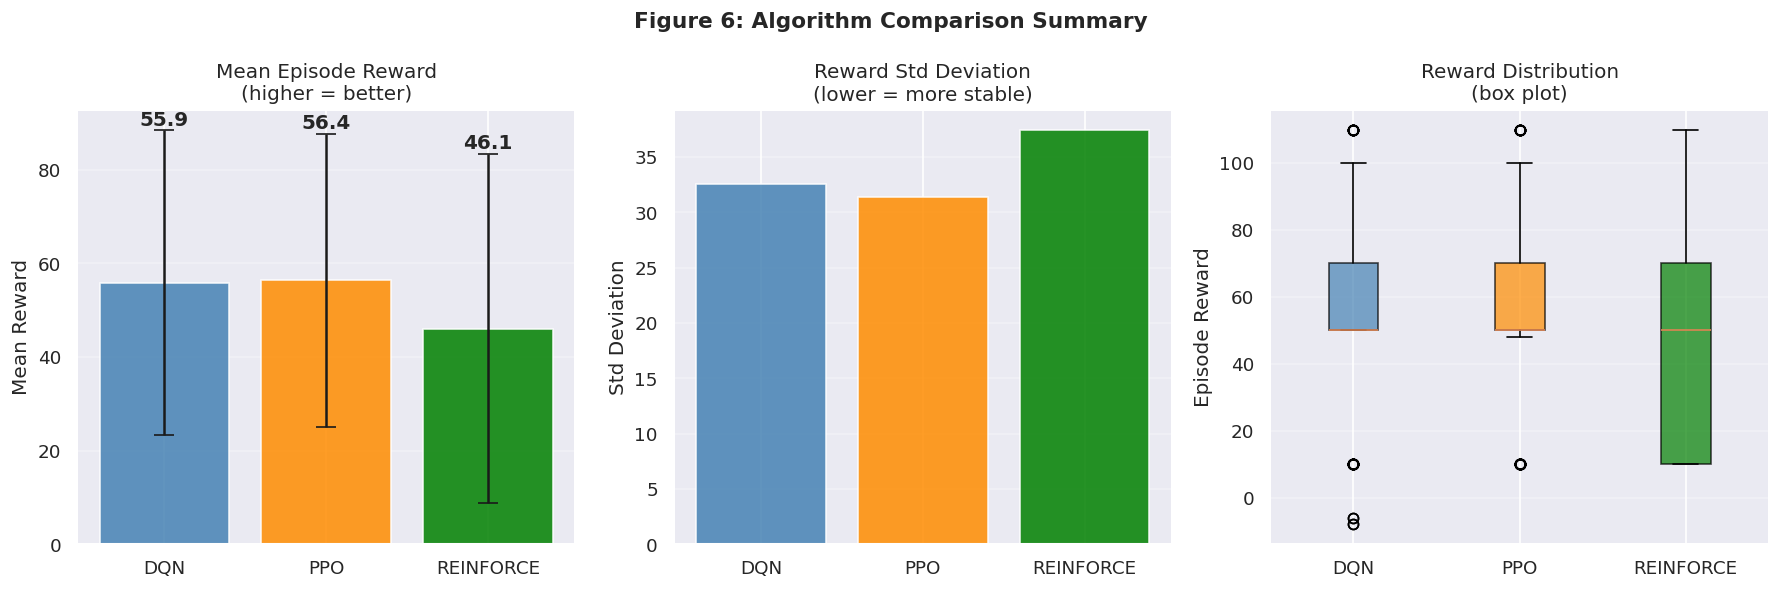

Saved: graph6_algorithm_summary.png


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Figure 6: Algorithm Comparison Summary', fontsize=13, fontweight='bold')

algo_names  = ['DQN', 'PPO', 'REINFORCE']
algo_means  = [np.mean(dqn_rewards), np.mean(ppo_rewards), np.mean(rf_rewards)]
algo_stds   = [np.std(dqn_rewards),  np.std(ppo_rewards),  np.std(rf_rewards)]
algo_colors = ['steelblue', 'darkorange', 'green']

# Mean rewards
axes[0].bar(algo_names, algo_means, color=algo_colors, alpha=0.85,
            yerr=algo_stds, capsize=6)
axes[0].set_title('Mean Episode Reward\n(higher = better)')
axes[0].set_ylabel('Mean Reward')
axes[0].grid(axis='y', alpha=0.3)
for i, (m, s) in enumerate(zip(algo_means, algo_stds)):
    axes[0].text(i, m+s+1, f'{m:.1f}', ha='center', fontweight='bold')

# Std deviation
axes[1].bar(algo_names, algo_stds, color=algo_colors, alpha=0.85)
axes[1].set_title('Reward Std Deviation\n(lower = more stable)')
axes[1].set_ylabel('Std Deviation')
axes[1].grid(axis='y', alpha=0.3)

# Box plot
bp = axes[2].boxplot([dqn_rewards, ppo_rewards, rf_rewards],
                      tick_labels=algo_names, patch_artist=True)
for patch, color in zip(bp['boxes'], algo_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[2].set_title('Reward Distribution\n(box plot)')
axes[2].set_ylabel('Episode Reward')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('results/graph6_algorithm_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: graph6_algorithm_summary.png')

## Step 12 — Final Summary Table

In [12]:
dqn_df = pd.read_csv('results/dqn_results.csv')
ppo_df = pd.read_csv('results/ppo_results.csv')
rf_df  = pd.read_csv('results/reinforce_results.csv')

print('='*60)
print('  FINAL RESULTS SUMMARY')
print('='*60)
print(f'  Random Agent (baseline):  0.00')
print(f'  REINFORCE best:           {rf_df["Mean Reward"].max():.2f}')
print(f'  DQN best:                 {dqn_df["Mean Reward"].max():.2f}')
print(f'  PPO best:                 {ppo_df["Mean Reward"].max():.2f}')
print('='*60)

winner = max([
    ('DQN',       dqn_df['Mean Reward'].max()),
    ('PPO',       ppo_df['Mean Reward'].max()),
    ('REINFORCE', rf_df['Mean Reward'].max()),
], key=lambda x: x[1])

print(f'  Best overall algorithm: {winner[0]} ({winner[1]:.2f})')
print('='*60)

  FINAL RESULTS SUMMARY
  Random Agent (baseline):  0.00
  REINFORCE best:           59.00
  DQN best:                 66.95
  PPO best:                 67.00
  Best overall algorithm: PPO (67.00)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Step 13 — Save All Graphs to Drive + Download

In [13]:
import shutil
from google.colab import files

# Save all graphs to Drive
DRIVE_RESULTS = '/content/drive/MyDrive/sista_health_rl/results'
for graph in ['graph1_cumulative_rewards.png', 'graph2_dqn_objective.png',
              'graph3_entropy_curves.png',      'graph4_convergence.png',
              'graph5_generalization.png',      'graph6_algorithm_summary.png']:
    shutil.copy(f'results/{graph}', f'{DRIVE_RESULTS}/{graph}')

print('All graphs saved to Drive!')

# Download zip
shutil.make_archive('comparison_results', 'zip', 'results')
files.download('comparison_results.zip')
print('Downloaded!')

All graphs saved to Drive!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded!
